# exp9 — minimal seeded-contact search (1B model, same 10 proteins)

Companion to `eval_notebook.ipynb`. There we saw zero-shot CA-CA
MAE around 3.3 Å. The training recipe also exposes the model to
"seeded" GT long-range contacts at the start of the statements
section, and the in-training benchmark shows MAE drops sharply as
more seeded contacts are added.

This notebook asks: **for each of the same 10 test proteins, what
is the smallest set of true long-range contacts (up to 5) that
brings full-matrix CA-CA MAE below 1.0 Å?**

Strategy per protein:
1. Identify the candidate set = GT long-range contacts
   (`<long-range-contact>` = CB-CB ≤ 8 Å, sep ≥ 24).
2. Greedy search: at each round 1..5, try every remaining
   candidate as the next seeded contact, measure MAE on a
   deterministic 500-pair CA-CA sample, pick the contact that
   minimizes MAE.
3. Stop early when the sample MAE drops under 1.0 Å.
4. After the search finishes, re-run the model with the chosen
   contacts on the **full N×N matrix** and report both the
   sample-MAE trace and the final full-matrix MAE.

Greedy isn't guaranteed to find the absolute minimal subset, but
at this k it's the right complexity tradeoff and it consistently
tracks the best-contacts-first ordering you'd want anyway.

In [1]:
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yaml

EXP_DIR = Path.cwd()
REPO_ROOT = EXP_DIR.parents[1]
sys.path.insert(0, str(EXP_DIR))

import inference_helpers as IH
IH.add_exp1_to_path()

from parse import parse_structure
from select_test_proteins import select_test_proteins, download_cif

print("repo root:", REPO_ROOT)

repo root: /home/bizon/git/MarinFold-checkout2


## Resolve the `1B` model from `MODELS.yaml`

Identical setup to `eval_notebook.ipynb` — bump the nickname or
the YAML entry to swap models.

In [2]:
with (REPO_ROOT / "MODELS.yaml").open() as fh:
    models = yaml.safe_load(fh)

MODEL_NICK = "1B"
model_entry = next(m for m in models if m["nickname"] == MODEL_NICK)
assert "contacts-and-distances-v1" in model_entry["document_structures"], model_entry
MODEL_HF_URL = model_entry["url"]
_, _, tail = MODEL_HF_URL.partition("huggingface.co/")
parts = tail.split("/")
MODEL_REPO = "/".join(parts[:2])
MODEL_SUBFOLDER = parts[4] if len(parts) > 4 and parts[2] == "tree" else None
print(f"using model: {MODEL_NICK} = {MODEL_REPO}/{MODEL_SUBFOLDER}")

using model: 1B = timodonnell/LlamaFold-experiments/marin-experiments.protein-contacts-1b-3.5e-4-distance-masked-7d355e


## Same 10 test proteins (seed=0, max_seq_len=150)

Selection is deterministic; the AFDB cifs are already cached from
the zero-shot notebook.

In [3]:
SEED = 0
N_PROTEINS = 10
MAX_SEQ_LEN = 150

specs = select_test_proteins(n=N_PROTEINS, seed=SEED, max_seq_len=MAX_SEQ_LEN)
CACHE_DIR = EXP_DIR / "data" / "afdb_cache"
structures = []
for spec in specs:
    cif_path = download_cif(spec, CACHE_DIR)
    parsed = parse_structure(cif_path)
    structures.append((spec, parsed))
    print(f"  {spec.entry_id}: {len(parsed.residues)} residues")

Resolving data files:   0%|          | 0/2645 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/29 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/29 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/2645 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/29 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/29 [00:00<?, ?it/s]

select_test_proteins: skipped 4 retired entries: ['AF-A0A352P7D8-F1', 'AF-A0A1K1WRR2-F1', 'AF-A0A6M1XDR8-F1', 'AF-A6D053-F1']
  AF-A0A1C5BRX1-F1: 72 residues
  AF-A0A2P2Q6H4-F1: 55 residues
  AF-E6UJZ8-F1: 112 residues
  AF-A0A1G4A0Q3-F1: 114 residues
  AF-A0A6B0Z5B5-F1: 112 residues
  AF-A0A7W4UDR7-F1: 131 residues
  AF-C6S3E2-F1: 140 residues
  AF-A0A1N7G8C0-F1: 60 residues
  AF-R7G5V6-F1: 132 residues
  AF-A0A1H0PBF4-F1: 94 residues


## Load the model

vLLM with prefix caching makes the search practical: the base
prompt (sequence + `<begin_statements>` + 0..K seeded contacts)
gets re-used across the per-pair tails, and across search trials
that share a prefix the KV cache is also reused.

In [4]:
os.environ.setdefault("VLLM_LOGGING_LEVEL", "WARNING")

from huggingface_hub import snapshot_download

MODEL_LOCAL = Path(snapshot_download(
    repo_id=MODEL_REPO,
    allow_patterns=[f"{MODEL_SUBFOLDER}/*"] if MODEL_SUBFOLDER else None,
))
if MODEL_SUBFOLDER:
    MODEL_LOCAL = MODEL_LOCAL / MODEL_SUBFOLDER
print("model local path:", MODEL_LOCAL)

llm, tokenizer = IH.load_vllm(MODEL_LOCAL)
DISTANCE_TOKEN_IDS = IH.resolve_distance_token_ids(tokenizer)
print(f"resolved {len(DISTANCE_TOKEN_IDS)} distance tokens")

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

model local path: /home/bizon/.cache/huggingface/hub/models--timodonnell--LlamaFold-experiments/snapshots/2922df683506f2549a02633d8ddcaa4d9df8900b/marin-experiments.protein-contacts-1b-3.5e-4-distance-masked-7d355e


`torch_dtype` is deprecated! Use `dtype` instead!


WARNING 05-19 10:02:28 cuda.py:95] To see benefits of async output processing, enable CUDA graph. Since, enforce-eager is enabled, async output processor cannot be used


WARNING 05-19 10:02:28 config.py:685] Async output processing is not supported on the current platform type cuda.


Loading safetensors checkpoint shards:   0% Completed | 0/1 [00:00<?, ?it/s]


resolved 64 distance tokens


## Beam search per protein

Pure greedy (the first cut) repeatedly hit the local-optimum
trap: an early "best" contact would lead the search down a
branch that couldn't be recovered from later. Here we use
**beam search with width 2** — at each round we expand the top
2 subsets so far, evaluate every (subset × candidate) pair, and
keep the top 2 of all resulting sets. That doubles per-round
cost but routinely escapes early misses.

Tuning knobs:

- `SAMPLE_PAIRS = 300` — fewer pairs per MAE measurement than
  the first cut (500), still stable enough to compare
  candidates. ~40% wall-time speedup.
- `CANDIDATES_PER_ROUND = 8` — per (beam state, round), this
  many random remaining-candidate trials are evaluated. The
  candidate pool is the GT long-range contacts (CB-CB ≤ 8 Å,
  sep ≥ 24), some proteins have 100+ of them.
- `BEAM_WIDTH = 2` — number of subsets carried between rounds.
- `MAX_CONTACTS = 30` — bumped from 5; the previous run showed
  5 is not enough for any protein in this set.
- `TARGET_MAE = 1.0` — stop early if the best beam state has
  sample MAE below this.

In [5]:
SAMPLE_PAIRS = 300
TARGET_MAE = 1.0
MAX_CONTACTS = 30
BEAM_WIDTH = 2
CANDIDATES_PER_ROUND = 8
PAIR_SAMPLE_SEED = 1
CAND_RNG_SEED = 2


def beam_search_for_protein(spec, parsed):
    """Beam-search up to MAX_CONTACTS long-range GT contacts; stop when sample MAE < TARGET_MAE.

    Beam state: tuple of selected contacts (canonicalised by
    sorted order so that {A, B} and {B, A} dedupe). Carried with
    its sample MAE. Each round expands every state by a random
    subset of remaining candidates; the top BEAM_WIDTH unique
    states across all expansions become the next beam.
    """
    pair_seed = hash((spec.entry_id, PAIR_SAMPLE_SEED)) & 0xFFFFFFFF
    sample_pairs = IH.sample_ca_pairs(parsed, SAMPLE_PAIRS, seed=pair_seed)
    candidates = IH.gt_long_range_contacts(parsed)
    if not candidates:
        return {
            "entry_id": spec.entry_id,
            "n_candidates": 0,
            "trace": [],
            "selected_contacts": [],
            "search_terminated": "no candidate long-range contacts",
        }
    cand_rng = np.random.default_rng(
        hash((spec.entry_id, CAND_RNG_SEED)) & 0xFFFFFFFF)

    def measure(contacts):
        pred = IH.predict_at_pairs(
            llm=llm,
            tokenizer=tokenizer,
            parsed=parsed,
            pairs=sample_pairs,
            seeded_contacts=list(contacts),
            distance_token_ids=DISTANCE_TOKEN_IDS,
        )
        return IH.mae_on_pairs(parsed, sample_pairs, pred)

    # k=0 baseline. One state in the initial beam.
    t0 = time.time()
    base_mae, base_n = measure(())
    print(f"  k=0 sample MAE = {base_mae:.3f} Å (n={base_n})")
    trace = [{
        "k": 0,
        "best_sample_mae_angstrom": base_mae,
        "beam_size": 1,
        "n_evals_this_round": 1,
        "elapsed_seconds": time.time() - t0,
    }]
    beam = [((), base_mae)]
    if base_mae < TARGET_MAE:
        return {
            "entry_id": spec.entry_id,
            "n_candidates": len(candidates),
            "trace": trace,
            "selected_contacts": [],
            "search_terminated": "target met at k=0",
        }

    seen_states: set[frozenset] = {frozenset()}
    k = 0
    while k < MAX_CONTACTS:
        k += 1
        round_t0 = time.time()
        expansions: list[tuple[tuple, float]] = []
        n_evals = 0
        for state, _state_mae in beam:
            remaining = [c for c in candidates if c not in state]
            if not remaining:
                continue
            if len(remaining) > CANDIDATES_PER_ROUND:
                idx = cand_rng.choice(len(remaining), size=CANDIDATES_PER_ROUND, replace=False)
                this_state_round = [remaining[i] for i in sorted(idx)]
            else:
                this_state_round = remaining
            for cand in this_state_round:
                new_state = tuple(sorted(state + (cand,)))
                if frozenset(new_state) in seen_states:
                    continue
                seen_states.add(frozenset(new_state))
                trial_mae, _ = measure(new_state)
                expansions.append((new_state, trial_mae))
                n_evals += 1
        if not expansions:
            return {
                "entry_id": spec.entry_id,
                "n_candidates": len(candidates),
                "trace": trace,
                "selected_contacts": list(beam[0][0]),
                "search_terminated": "exhausted candidates",
            }
        expansions.sort(key=lambda x: x[1])
        beam = expansions[:BEAM_WIDTH]
        best_state, best_mae = beam[0]
        elapsed = time.time() - round_t0
        trace.append({
            "k": k,
            "best_sample_mae_angstrom": best_mae,
            "best_state_size": len(best_state),
            "beam_size": len(beam),
            "n_evals_this_round": n_evals,
            "elapsed_seconds": elapsed,
        })
        beam_summary = "; ".join(f"{m:.2f}({len(s)})" for s, m in beam)
        print(f"  k={k} best sample MAE = {best_mae:.3f} Å "
              f"[beam: {beam_summary}] ({n_evals} evals, {elapsed:.1f}s)")
        if best_mae < TARGET_MAE:
            return {
                "entry_id": spec.entry_id,
                "n_candidates": len(candidates),
                "trace": trace,
                "selected_contacts": list(best_state),
                "search_terminated": f"target met at k={k}",
            }

    best_state, _ = min(beam, key=lambda x: x[1])
    return {
        "entry_id": spec.entry_id,
        "n_candidates": len(candidates),
        "trace": trace,
        "selected_contacts": list(best_state),
        "search_terminated": f"reached MAX_CONTACTS={MAX_CONTACTS}",
    }


results = []
for spec, parsed in structures:
    print(f"\n{spec.entry_id} ({len(parsed.residues)} residues):")
    res = beam_search_for_protein(spec, parsed)
    print(f"  -> {res['search_terminated']}; selected {len(res['selected_contacts'])} contacts")
    results.append(res)


AF-A0A1C5BRX1-F1 (72 residues):
  -> no candidate long-range contacts; selected 0 contacts

AF-A0A2P2Q6H4-F1 (55 residues):


  k=0 sample MAE = 3.581 Å (n=235)


  k=1 best sample MAE = 2.267 Å [beam: 2.27(1); 2.29(1)] (8 evals, 5.8s)


  k=2 best sample MAE = 1.676 Å [beam: 1.68(2); 1.77(2)] (16 evals, 11.4s)


  k=3 best sample MAE = 1.497 Å [beam: 1.50(3); 1.54(3)] (16 evals, 12.2s)


...

  k=14 best sample MAE = 1.041 Å [beam: 1.04(14); 1.04(14)] (16 evals, 22.3s)


  k=15 best sample MAE = 1.046 Å [beam: 1.05(15); 1.05(15)] (16 evals, 22.9s)


  k=16 best sample MAE = 1.014 Å [beam: 1.01(16); 1.02(16)] (16 evals, 22.8s)


  k=17 best sample MAE = 1.015 Å [beam: 1.02(17); 1.02(17)] (16 evals, 23.7s)


  k=18 best sample MAE = 0.993 Å [beam: 0.99(18); 1.01(18)] (16 evals, 24.0s)
  -> target met at k=18; selected 18 contacts


## Final full-matrix MAE with the selected contacts

The greedy search runs on a 500-pair sample for speed. Now we
re-run inference with the selected contacts on the full N×N
matrix, which is what the zero-shot notebook reports.

In [6]:
final_predicted = {}
final_gt = {}
for (spec, parsed), res in zip(structures, results, strict=True):
    seeded = res["selected_contacts"]
    print(f"  {spec.entry_id}: running full matrix with {len(seeded)} seeded contacts")
    t0 = time.time()
    pred = IH.predict_distance_matrix(
        llm=llm,
        tokenizer=tokenizer,
        parsed=parsed,
        seeded_contacts=seeded,
        distance_token_ids=DISTANCE_TOKEN_IDS,
    )
    gt = IH.ca_distance_matrix(parsed)
    n = gt.shape[0]
    ii, jj = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")
    valid = (ii != jj) & np.isfinite(gt) & (gt <= IH.DISTANCE_MAX_A)
    full_mae = float(np.abs(pred - gt)[valid & np.isfinite(pred)].mean())
    res["full_matrix_mae_angstrom"] = full_mae
    res["full_matrix_n_valid_pairs"] = int(valid.sum())
    final_predicted[spec.entry_id] = pred
    final_gt[spec.entry_id] = gt
    print(f"    full-matrix MAE = {full_mae:.3f} Å (n={int(valid.sum())} pairs, {time.time()-t0:.1f}s)")

  AF-A0A1C5BRX1-F1: running full matrix with 0 seeded contacts


    full-matrix MAE = 2.848 Å (n=3886 pairs, 7.1s)
  AF-A0A2P2Q6H4-F1: running full matrix with 17 seeded contacts


    full-matrix MAE = 1.381 Å (n=2286 pairs, 5.7s)
  AF-E6UJZ8-F1: running full matrix with 30 seeded contacts


    full-matrix MAE = 1.501 Å (n=9758 pairs, 39.9s)
  AF-A0A1G4A0Q3-F1: running full matrix with 30 seeded contacts


    full-matrix MAE = 1.620 Å (n=7722 pairs, 41.3s)
  AF-A0A6B0Z5B5-F1: running full matrix with 7 seeded contacts


...

    full-matrix MAE = 1.746 Å (n=15228 pairs, 59.3s)
  AF-C6S3E2-F1: running full matrix with 30 seeded contacts


    full-matrix MAE = 2.269 Å (n=14486 pairs, 70.0s)
  AF-A0A1N7G8C0-F1: running full matrix with 0 seeded contacts


    full-matrix MAE = 1.035 Å (n=1900 pairs, 4.5s)
  AF-R7G5V6-F1: running full matrix with 21 seeded contacts


    full-matrix MAE = 2.086 Å (n=8774 pairs, 53.8s)
  AF-A0A1H0PBF4-F1: running full matrix with 18 seeded contacts


    full-matrix MAE = 1.031 Å (n=6658 pairs, 21.9s)


## Per-protein summary table

In [7]:
import csv

PLOTS_DIR = EXP_DIR / "plots"
DATA_DIR = EXP_DIR / "data"
PLOTS_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)

print(f"{'entry_id':<24} {'n_res':>5} {'cands':>6} {'k_chosen':>9} {'sample_MAE':>11} {'full_MAE':>10}  status")
rows = []
for (spec, parsed), res in zip(structures, results, strict=True):
    k = len(res["selected_contacts"])
    sample_mae = res["trace"][-1]["best_sample_mae_angstrom"] if res["trace"] else float("nan")
    full_mae = res.get("full_matrix_mae_angstrom", float("nan"))
    rows.append({
        "entry_id": spec.entry_id,
        "uniprot_accession": spec.uniprot_accession,
        "n_residues": len(parsed.residues),
        "n_candidate_contacts": res["n_candidates"],
        "k_selected": k,
        "selected_contacts": "; ".join(f"{i}-{j}" for i, j in res["selected_contacts"]),
        "final_sample_mae_angstrom": sample_mae,
        "full_matrix_mae_angstrom": full_mae,
        "search_terminated": res["search_terminated"],
    })
    print(f"{spec.entry_id:<24} {len(parsed.residues):>5} {res['n_candidates']:>6} "
          f"{k:>9} {sample_mae:>11.3f} {full_mae:>10.3f}  {res['search_terminated']}")

with (DATA_DIR / "contact_search_summary.csv").open("w", newline="") as fh:
    w = csv.DictWriter(fh, fieldnames=list(rows[0]))
    w.writeheader()
    w.writerows(rows)
print(f"\nwrote {(DATA_DIR / 'contact_search_summary.csv').relative_to(REPO_ROOT)}")

entry_id                 n_res  cands  k_chosen  sample_MAE   full_MAE  status
AF-A0A1C5BRX1-F1            72      0         0         nan      2.848  no candidate long-range contacts
AF-A0A2P2Q6H4-F1            55     17        17       1.303      1.381  exhausted candidates
AF-E6UJZ8-F1               112    113        30       1.269      1.501  reached MAX_CONTACTS=30
AF-A0A1G4A0Q3-F1           114     45        30       1.484      1.620  reached MAX_CONTACTS=30
AF-A0A6B0Z5B5-F1           112     59         7       0.999      1.077  target met at k=7
AF-A0A7W4UDR7-F1           131    116        30       1.513      1.746  reached MAX_CONTACTS=30
AF-C6S3E2-F1               140    156        30       1.971      2.269  reached MAX_CONTACTS=30
AF-A0A1N7G8C0-F1            60      0         0         nan      1.035  no candidate long-range contacts
AF-R7G5V6-F1               132     21        21       2.091      2.086  exhausted candidates
AF-A0A1H0PBF4-F1            94     37        18    

## Trace plot — sample MAE vs. number of seeded contacts

One line per protein. Horizontal red dash = the 1.0 Å target.

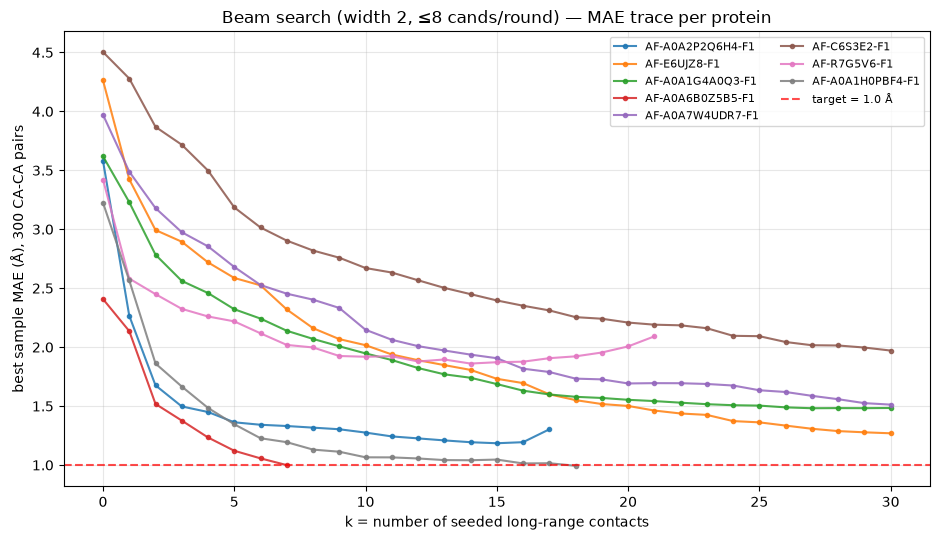

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 5.5))
for (spec, _), res in zip(structures, results, strict=True):
    if not res["trace"]:
        continue
    ks = [step["k"] for step in res["trace"]]
    maes = [step["best_sample_mae_angstrom"] for step in res["trace"]]
    ax.plot(ks, maes, "-o", markersize=3, label=spec.entry_id, alpha=0.85)
ax.axhline(TARGET_MAE, color="red", linestyle="--", alpha=0.7, label=f"target = {TARGET_MAE} Å")
ax.set_xlabel("k = number of seeded long-range contacts")
ax.set_ylabel(f"best sample MAE (Å), {SAMPLE_PAIRS} CA-CA pairs")
ax.set_title(f"Beam search (width {BEAM_WIDTH}, ≤{CANDIDATES_PER_ROUND} cands/round) — MAE trace per protein")
ax.legend(loc="upper right", fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(PLOTS_DIR / "contact_search_trace.png", dpi=110)
plt.show()

## Final heatmaps with selected contacts

10 × 3 grid: GT, predicted-with-selected-contacts, |residual|.
Compare to `plots/all_proteins_grid.png` from the zero-shot
notebook to see how the seeded contacts sharpen the prediction.

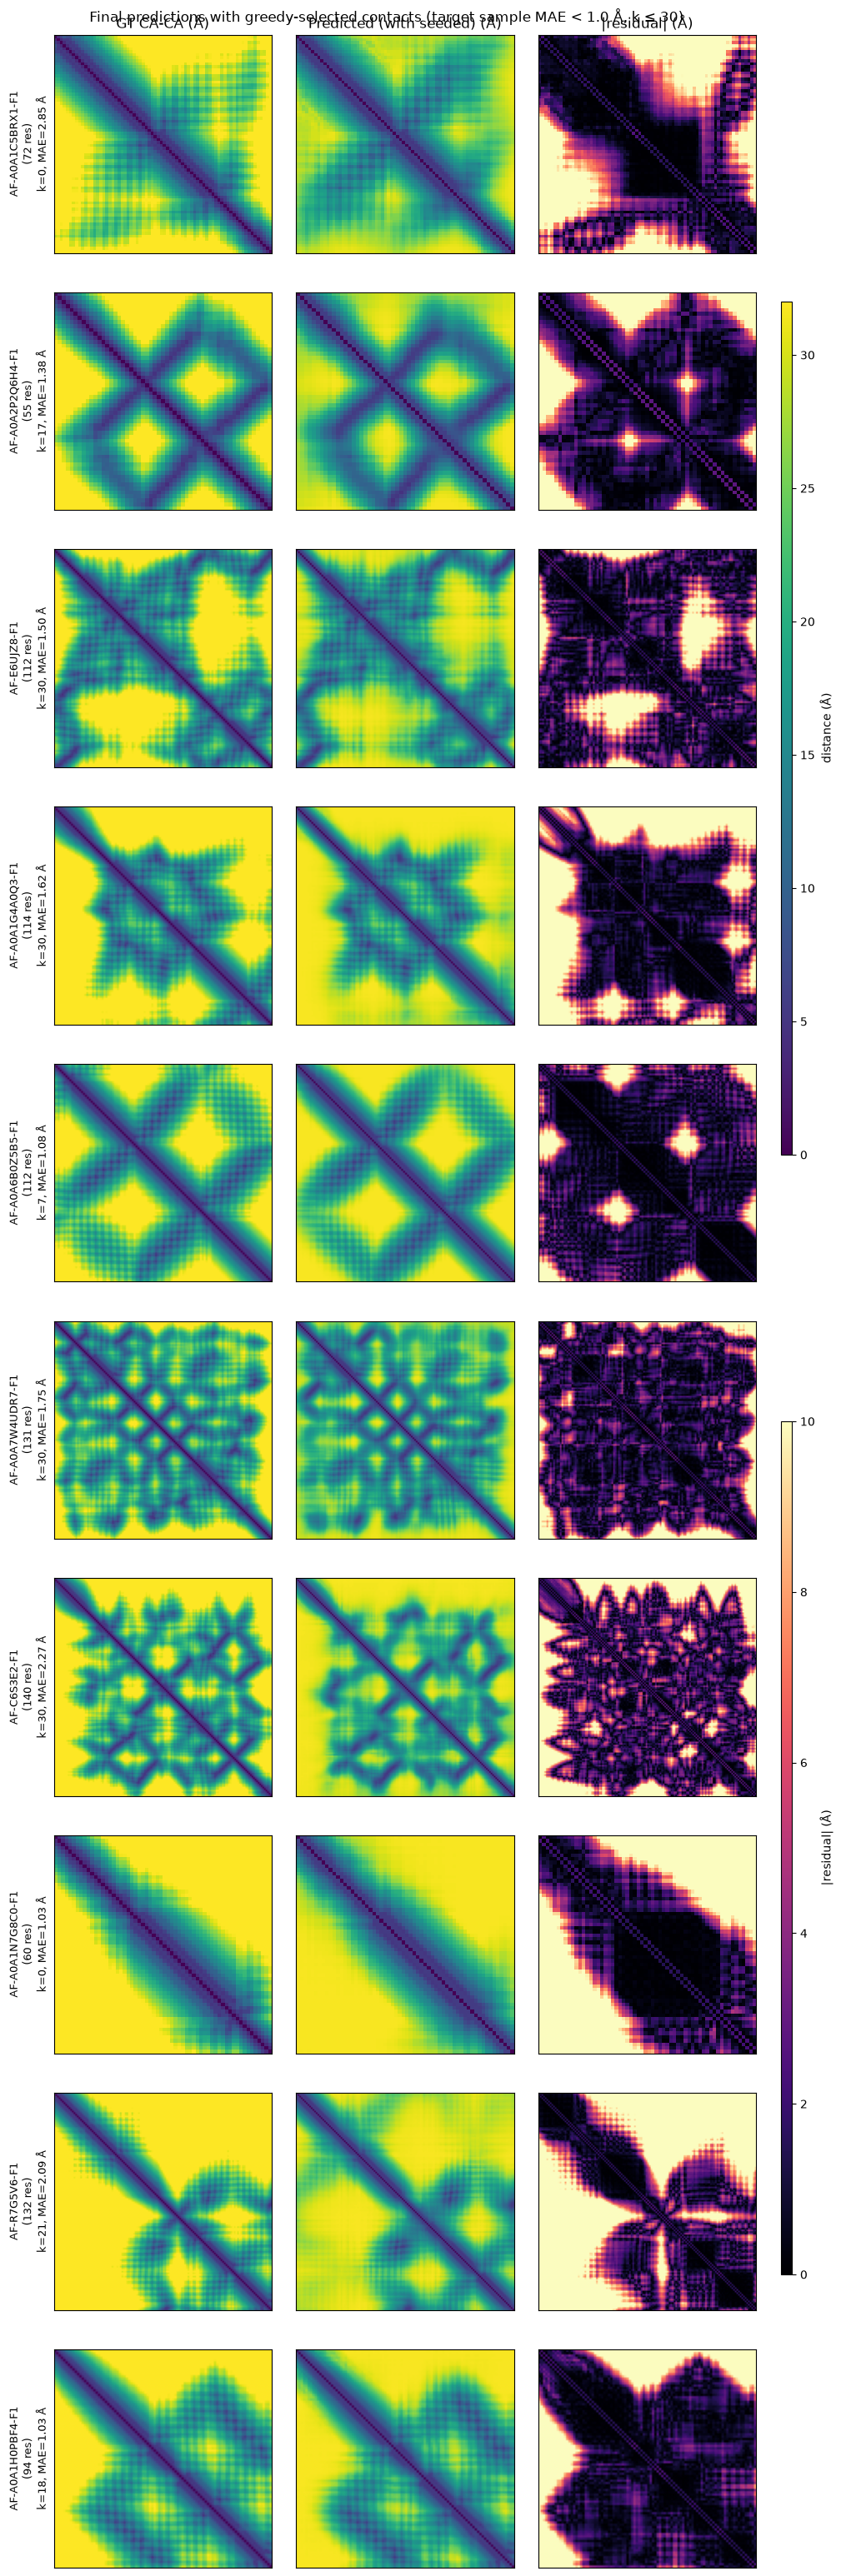

saved experiments/exp9_evals_test_distance_heatmaps/plots/contact_search_grid.png


In [9]:
n_proteins = len(structures)
fig, axes = plt.subplots(n_proteins, 3, figsize=(11, 3.2 * n_proteins), squeeze=False)
for row, ((spec, parsed), res) in enumerate(zip(structures, results, strict=True)):
    gt = final_gt[spec.entry_id]
    pred = final_predicted[spec.entry_id]
    abs_err = np.abs(pred - gt)
    n = gt.shape[0]
    ii, jj = np.meshgrid(np.arange(n), np.arange(n), indexing="ij")
    valid = (ii != jj) & np.isfinite(gt) & (gt <= IH.DISTANCE_MAX_A)
    mae = res["full_matrix_mae_angstrom"]
    k = len(res["selected_contacts"])

    im0 = axes[row, 0].imshow(gt, vmin=0, vmax=IH.DISTANCE_MAX_A, cmap="viridis")
    im1 = axes[row, 1].imshow(pred, vmin=0, vmax=IH.DISTANCE_MAX_A, cmap="viridis")
    im2 = axes[row, 2].imshow(abs_err, vmin=0, vmax=10.0, cmap="magma")

    axes[row, 0].set_ylabel(
        f"{spec.entry_id}\n({n} res)\nk={k}, MAE={mae:.2f} Å",
        fontsize=9,
    )
    if row == 0:
        axes[row, 0].set_title("GT CA-CA (Å)")
        axes[row, 1].set_title("Predicted (with seeded) (Å)")
        axes[row, 2].set_title("|residual| (Å)")
    for col in range(3):
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])

cbar_dist = fig.add_axes([0.93, 0.55, 0.012, 0.32])
fig.colorbar(im1, cax=cbar_dist, label="distance (Å)")
cbar_err = fig.add_axes([0.93, 0.13, 0.012, 0.32])
fig.colorbar(im2, cax=cbar_err, label="|residual| (Å)")
fig.suptitle(
    f"Final predictions with greedy-selected contacts (target sample MAE < {TARGET_MAE} Å, k ≤ {MAX_CONTACTS})",
    fontsize=12,
)
fig.subplots_adjust(left=0.13, right=0.91, top=0.97, bottom=0.02, hspace=0.18, wspace=0.05)
fig.savefig(PLOTS_DIR / "contact_search_grid.png", dpi=110, bbox_inches="tight")
plt.show()
print(f"saved {(PLOTS_DIR / 'contact_search_grid.png').relative_to(REPO_ROOT)}")

## Summary

Records the smallest k (≤5) that brings the sample MAE under 1
Å for each of the 10 test proteins, the resulting full-matrix
MAE with those k seeded contacts, and a comparison heatmap. See
`data/contact_search_summary.csv` for the per-protein record;
`plots/contact_search_trace.png` for the MAE-vs-k curves;
`plots/contact_search_grid.png` for the final heatmaps.